## QA - chathead "mismatch"

When scraping chathead images, our scraper searched for `_chathead.png` across the entire page rather than scoping the search to the infobox. Many NPC pages actually don't have a chathead at all. So our approach worked perfectly fine for NPCs that **do** have a chat head, but grabbed something random for NPCs that don't. It basically found very small images at the bottom of the page in the navigation footer. It then grabbed the first image it could find, which is both (1) not of the NPC in question and (2) very, very small and low-res. 

Example: https://oldschool.runescape.wiki/w/Agitated_bees

Camille caught this by auditing mismatches between the NPC's name and the filename stem of the chathead URL. Oliver then did some spot-checks (see below)

Note: Camille surfaced 3 categories of "mismatches". Two were actually perfectly fine:
- URL-encoded special characters (ex: 50%25_Luke, A%27abla - the name and image match just fine, the URL is just percent-encoded). Fixed by adding unquote().
- Disambiguation suffixes (Academic_(1), Alan_(Farming_Guild)). The wiki appends extra context to the filename, so the NPC name doesn't match perfectly, but still the correct image.

### We will fix the chat head issue by finding mismatches and deleting the faux chatheads

Note: the full body images are fine. The scraper was more properly scoped to just the infobox for those images. Also NPCs almost always have a body image, even if no chathead. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from urllib.parse import unquote
from PIL import Image

In [2]:
df = pd.read_csv("../data/npc.csv")

# Check for mismatches between Name and chathead_url filename
def extract_filename_stem(url):
    if pd.isna(url):
        return None
    # handle thumbnail paths like .../thumb/Foo_chathead.png/23px-Foo_chathead.png
    # the real subject name is usually in the /thumb/ segment, not the final 23px- one
    m = re.search(r'/thumb/([^/]+?)_chathead\.png', url)
    if m:
        return unquote(m.group(1))
    m = re.search(r'/([^/]+?)_chathead\.png', url)
    if m:
        return unquote(m.group(1))
    return None

def normalize(s):
    if pd.isna(s):
        return None
    return re.sub(r'[^a-z0-9]', '', s.lower())

df["chathead_filename_stem"] = df["chathead_url"].apply(extract_filename_stem)
df["name_norm"] = df["Name"].apply(normalize)
df["filename_norm"] = df["chathead_filename_stem"].apply(normalize)

# genuine mismatch: filename shares NO words with name (catches wrong-NPC images, ignores disambiguation suffixes)
def shares_any_word(name, filename):
    if pd.isna(name) or pd.isna(filename):
        return False
    name_words = set(re.sub(r'[^a-z0-9]', ' ', name.lower()).split())
    filename_words = set(re.sub(r'[^a-z0-9]', ' ', filename.lower()).split())
    return bool(name_words & filename_words)

df["genuine_mismatch"] = (
    df["chathead_filename_stem"].notna()
    & df["Name"].notna()
    & ~df.apply(lambda r: shares_any_word(r["Name"], r["chathead_filename_stem"]), axis=1)
)

# has_chathead: True only if chathead_url exists and isn't a genuine mismatch
df["has_chathead"] = df["chathead_url"].notna() & ~df["genuine_mismatch"]

print(f"Total rows with chathead_url: {df['chathead_url'].notna().sum()}")
print(f"Genuine mismatches (wrong NPC image): {df['genuine_mismatch'].sum()}")
print(f"has_chathead (usable): {df['has_chathead'].sum()}")

# inspect
mismatches = df[df["genuine_mismatch"]][["id", "Name", "chathead_filename_stem"]].reset_index(drop=True)
print(mismatches.to_string())

Total rows with chathead_url: 4193
Genuine mismatches (wrong NPC image): 716
has_chathead (usable): 3477
       id                                       Name                      chathead_filename_stem
0       2                                 1337sp34kr                                 BigRedJapan
1       5                                    ? ? ? ?                           ?_?_?_?_(Unferth)
2       6                           A floating table                                      Diango
3      14                               Abyssal axon                  Golem_(Desert_Treasure_II)
4      15                           Abyssal guardian                              Wizard_Persten
5      16                              Abyssal leech                              Wizard_Persten
6      18                         Abyssal pathfinder                                 Lil'viathan
7      20                             Abyssal walker                              Wizard_Persten
8      28             

## Example of 4 NPCs with incorrect chat heads

Top row shows the corresponding image in /bodies. They are correct. Bottom row shows the corresponding chat head we grabbed. Notice how they are all wrong and low-res. 

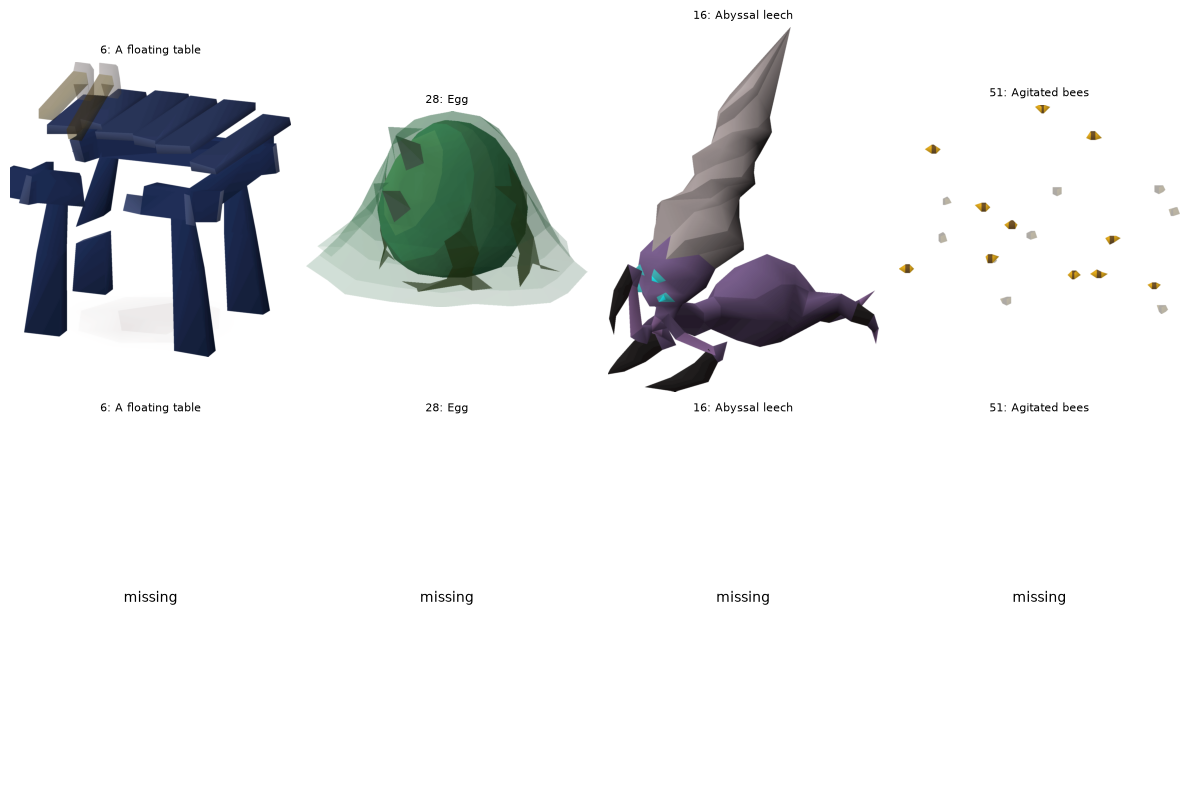

In [5]:
check_ids = [6, 28, 16, 51]

fig, axes = plt.subplots(2, len(check_ids), figsize=(len(check_ids) * 3, 8))
for col, npc_id in enumerate(check_ids):
    name = df.loc[df["id"] == npc_id, "Name"].values[0]
    for row, folder in enumerate(["bodies", "chatheads"]):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/{folder}/{npc_id}.png")
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.set_title(f"{npc_id}: {name}", fontsize=8)
        ax.set_ylabel(folder, fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

## More examples
### These should all be faux

Low-res, small images pulled from the nav box, not from the NPC content

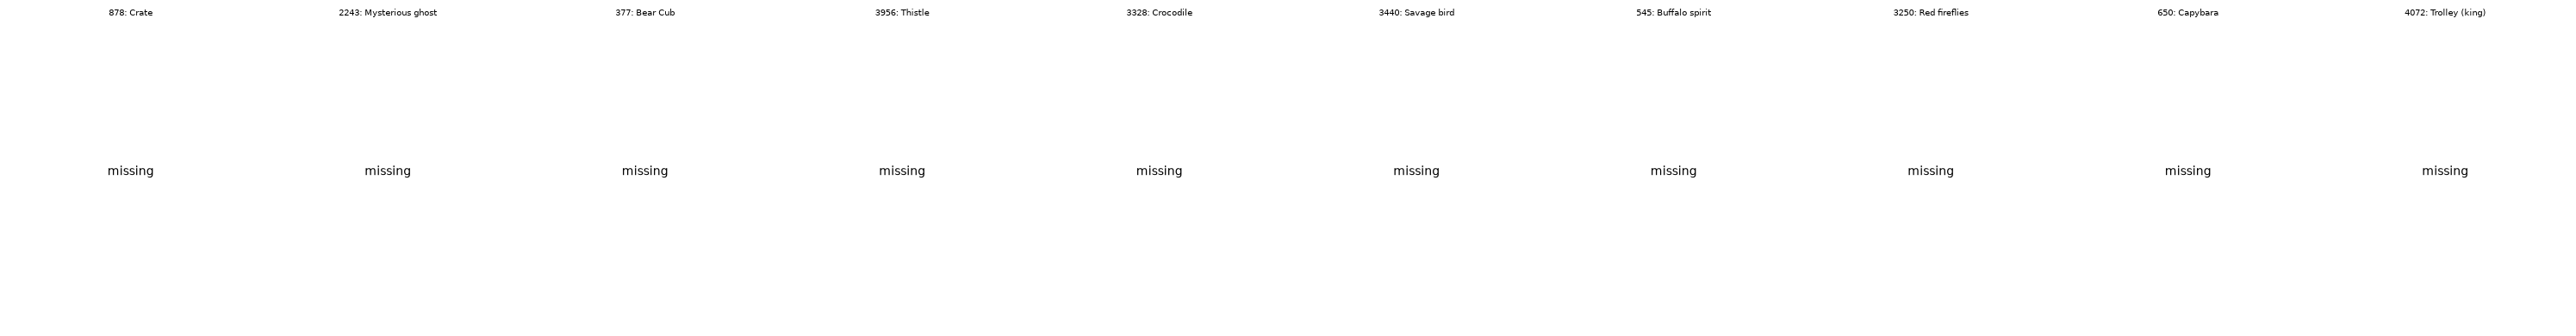

In [3]:
sample = mismatches.sample(10, random_state=42)

fig, axes = plt.subplots(1, 10, figsize=(30, 4))
for ax, (_, row) in zip(axes, sample.iterrows()):
    npc_id = row["id"]
    name = row["Name"]
    try:
        img = Image.open(f"../data/chatheads/{npc_id}.png")
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, "missing", ha="center")
    ax.set_title(f"{npc_id}: {name}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Fix

simply delete chathead images flagged as mismatches

In [4]:
# delete chathead images flagged as genuine mismatches
for npc_id in df[df["genuine_mismatch"]]["id"]:
    path = f"../data/chatheads/{npc_id}.png"
    if os.path.exists(path):
        os.remove(path)

# should print "Deleted 716 bad chathead images"
print(f"Deleted {df['genuine_mismatch'].sum()} bad chathead images")

Deleted 716 bad chathead images
